## 1. Setup

In [1]:
import os, math, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

random.seed(42)
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────
behaviors_path = "data/MINDsmall_train/behaviors.tsv"
news_path      = "data/MINDsmall_train/news.tsv"
bbc_folder     = "data/BBC"

## 2. Load MIND Data

In [2]:
behaviors_cols = ["impression_id", "user_id", "time", "history", "impressions"]
news_cols      = ["news_id", "category", "subcategory", "title", "abstract",
                  "url", "title_entities", "abstract_entities"]

behaviors = pd.read_csv(behaviors_path, sep="\t", header=None, names=behaviors_cols)
news = pd.read_csv(news_path,sep="\t", header=None, names=news_cols,usecols=range(8))


FileNotFoundError: [Errno 2] No such file or directory: 'data/MINDsmall_train/behaviors.tsv'

## 3. User Reading History → Genre Distribution

In [ ]:
# Keep only rows with a history and explode to one news_id per row
behaviors_history = behaviors[["user_id", "history"]].dropna().copy()
behaviors_history["history_list"] = behaviors_history["history"].str.split()

user_news = (
    behaviors_history[["user_id", "history_list"]]
    .explode("history_list")
    .rename(columns={"history_list": "news_id"})
)

# Attach news category and compute per-user category counts
user_news_category = user_news.merge(news[["news_id", "category"]], on="news_id", how="left")

user_category_count = (
    user_news_category
    .groupby(["user_id", "category"])
    .size()
    .reset_index(name="count")
)

user_total_count = (
    user_category_count
    .groupby("user_id")["count"]
    .sum()
    .reset_index(name="total_count")
)

user_category_pattern = (
    user_category_count
    .merge(user_total_count, on="user_id", how="left")
    .assign(percentage=lambda df: df["count"] / df["total_count"])
)


## 4. Map MIND Categories → BBC Genres

In [ ]:
category_map = {
    "autos":       "science-and-nature",
    "entertainment": "entertainment",
    "finance":     "documentaries",
    "foodanddrink": "lifestyle",
    "health":      "lifestyle",
    "kids":        "cbbc",
    "lifestyle":   "lifestyle",
    "middleeast":  "documentaries",
    "movies":      "films",
    "music":       "music",
    "news":        "documentaries",
    "sports":      "sports",
    "travel":      "lifestyle",
    "tv":          "entertainment",
    "video":       "entertainment",
    "weather":     "science-and-nature",
}

user_category_pattern["bbc_category"] = user_category_pattern["category"].map(category_map)

user_podcast_pattern = (
    user_category_pattern
    .groupby(["user_id", "bbc_category"])["count"]
    .sum()
    .reset_index()
)
user_podcast_pattern["total"] = (
    user_podcast_pattern.groupby("user_id")["count"].transform("sum")
)
user_podcast_pattern["percentage"] = (
    user_podcast_pattern["count"] / user_podcast_pattern["total"]
)


## 5. KMeans Persona Clustering

In [ ]:
user_genre_dist = (
    user_podcast_pattern
    .pivot(index="user_id", columns="bbc_category", values="percentage")
    .fillna(0)
)

# Assign total_views (news read count) per user
total_views_map = (behaviors_history.drop_duplicates("user_id").set_index("user_id")["history"].apply(lambda h: len(h.split())))
user_genre_dist["total_views"] = user_genre_dist.index.map(total_views_map)

kmeans = KMeans(n_clusters=6, n_init=20, random_state=42)
user_genre_dist["persona"] = kmeans.fit_predict(
    user_genre_dist.drop(columns=["total_views", "persona"], errors="ignore")
    .fillna(0)
    .values
)


## 6. Remove Activity Outliers (IQR per Persona)

In [ ]:
def remove_outliers_by_persona(df):
    parts = []
    for _, group in df.groupby("persona"):
        q1, q3 = group["total_views"].quantile([0.25, 0.75])
        iqr = q3 - q1
        mask = group["total_views"].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        parts.append(group[mask])
    return pd.concat(parts).sort_index()

user_genre_dist = remove_outliers_by_persona(user_genre_dist)


## 7. Visualise Persona Profiles

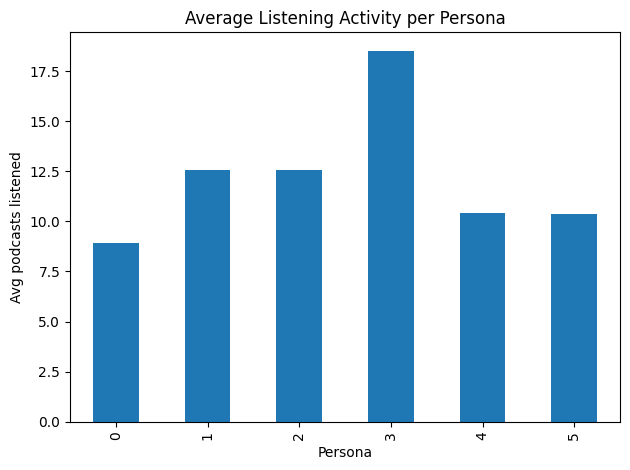

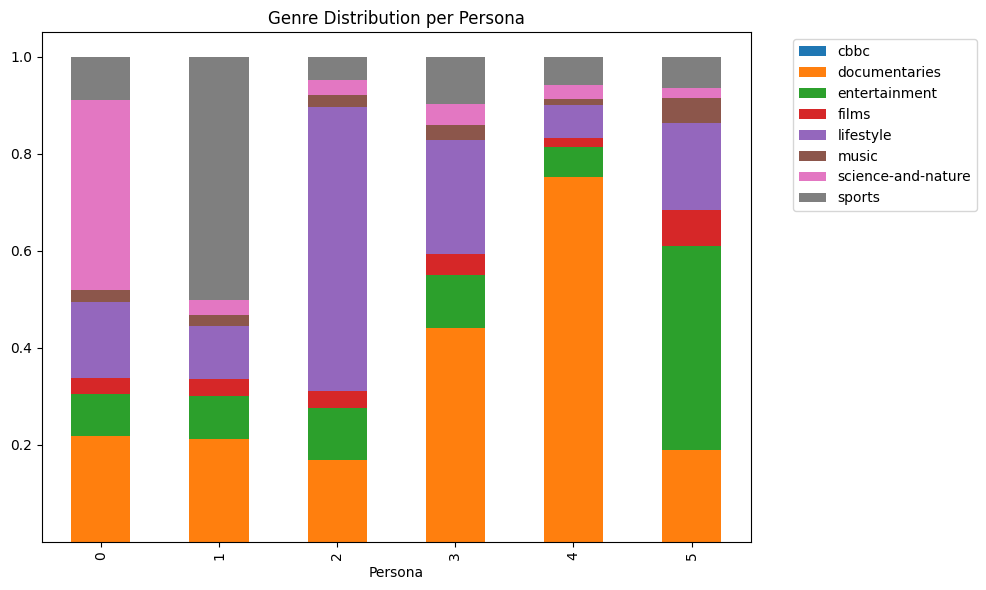

In [ ]:
non_genre_cols = ["persona", "total_views"]
genre_cols = [c for c in user_genre_dist.columns if c not in non_genre_cols]

# Average listening activity per persona
user_genre_dist.groupby("persona")["total_views"].mean().plot(kind="bar")
plt.xlabel("Persona")
plt.ylabel("Avg podcasts listened")
plt.title("Average Listening Activity per Persona")
plt.tight_layout()
plt.show()

# Genre distribution per persona
persona_genre_dist = user_genre_dist.groupby("persona")[genre_cols].mean()
persona_genre_dist.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.xlabel("Persona")
plt.title("Genre Distribution per Persona")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


## 8. Load BBC Catalogue

In [ ]:
bbc_data = {}
for file in os.listdir(bbc_folder):
    if file.endswith(".pkl"):
        genre_name = file.replace(".pkl", "")
        with open(os.path.join(bbc_folder, file), "rb") as f:
            obj = pickle.load(f)
        df = obj.copy() if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)
        df["duration_sec"] = pd.to_numeric(df["duration_sec"], errors="coerce")
        df = df.dropna(subset=["duration_sec"])
        df = df[df["duration_sec"] > 0].reset_index(drop=True)
        bbc_data[genre_name] = df

available_bbc_genres = set(bbc_data.keys())
usable_genres = [g for g in genre_cols if g in available_bbc_genres]


/var/folders/2w/126lfsqn7dq77wr9fbt2xkgc0000gn/T/ipykernel_33766/1233037067.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)
/var/folders/2w/126lfsqn7dq77wr9fbt2xkgc0000gn/T/ipykernel_33766/1233037067.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of 

## 9. Assign Popularity Groups & Quality Labels

In [ ]:
def assign_popularity_group(df):
    df = df.sample(frac=1, random_state=42).reset_index(drop=True).copy()
    n = len(df)
    if n == 0:
        return df
    head_cut = math.ceil(n * 0.10)
    mid_cut  = math.ceil(n * 0.30)
    df["popularity_group"] = [
        "head" if i < head_cut else "mid" if i < mid_cut else "tail"
        for i in range(n)
    ]
    df["popularity_rank"] = np.arange(1, n + 1)
    return df


def assign_quality_label(df):
    p_good_map = {"head": 0.60, "mid": 0.45, "tail": 0.30}
    df = df.copy()
    df["quality_label"] = [
        "good" if np.random.rand() < p_good_map[row["popularity_group"]] else "bad"
        for _, row in df.iterrows()
    ]
    return df


for genre in usable_genres:
    bbc_data[genre] = assign_quality_label(assign_popularity_group(bbc_data[genre]))


## 10. Sampling Helper Functions

In [ ]:
POP_GROUPS      = ["head", "mid", "tail"]
POP_GROUP_PROBS = [0.50, 0.30, 0.20]


def sample_listen_ratio(popularity_group, quality_label):
    if quality_label == "good":
        return np.random.uniform(0.65, 0.98)
    return np.random.uniform(0.03 if popularity_group == "tail" else 0.10, 0.60)


def generate_save(listen_ratio):
    p = 0.35 if listen_ratio >= 0.75 else 0.12 if listen_ratio >= 0.35 else 0.01
    return "yes" if np.random.rand() < p else "no"


def sample_podcast_from_genre(genre):
    df = bbc_data[genre]
    chosen_group = np.random.choice(POP_GROUPS, p=POP_GROUP_PROBS)
    subset = df[df["popularity_group"] == chosen_group]
    return (subset if len(subset) > 0 else df).sample(1).iloc[0]


def allocate_genre_counts(probs, total_views, genre_names):
    probs = np.array(probs, dtype=float)
    probs /= probs.sum()
    expected = probs * total_views
    base = np.floor(expected).astype(int)
    remainder = total_views - base.sum()
    for i in np.argsort(-(expected - base))[:remainder]:
        base[i] += 1
    return dict(zip(genre_names, base))


def get_item_type(popularity_group, quality_label):
    popular = popularity_group in ["head", "mid"]
    return ("popular" if popular else "unpopular") + "_" + quality_label


## 11. Generate Synthetic View History

In [ ]:
genre_prob_df = user_genre_dist[usable_genres].copy()
valid_users   = genre_prob_df[genre_prob_df.sum(axis=1) > 0].index
genre_prob_df = genre_prob_df.loc[valid_users].div(genre_prob_df.loc[valid_users].sum(axis=1), axis=0)
user_genre_dist = user_genre_dist.loc[valid_users].copy()

rows = []
for user_id in user_genre_dist.index:
    persona     = user_genre_dist.loc[user_id, "persona"]
    total_views = int(user_genre_dist.loc[user_id, "total_views"])
    probs       = genre_prob_df.loc[user_id].values
    genres      = genre_prob_df.columns.tolist()

    for chosen_genre, n_views in allocate_genre_counts(probs, total_views, genres).items():
        for _ in range(n_views):
            podcast = sample_podcast_from_genre(chosen_genre)
            duration_sec = pd.to_numeric(podcast["duration_sec"], errors="coerce")
            if pd.isna(duration_sec) or duration_sec <= 0:
                continue

            pop_group    = podcast["popularity_group"]
            quality      = podcast["quality_label"]
            listen_ratio = sample_listen_ratio(pop_group, quality)

            rows.append({
                "user_id":          user_id,
                "persona":          persona,
                "title":            podcast["title"],
                "category":         chosen_genre,
                "viewtime_sec":     max(int(round(duration_sec * listen_ratio)), 1),
                "save":             generate_save(listen_ratio),
                "duration_sec":     duration_sec,
                "listen_ratio":     round(listen_ratio, 3),
                "popularity_group": pop_group,
                "quality_label":    quality,
                "item_type":        get_item_type(pop_group, quality),
            })

synthetic_view_history = pd.DataFrame(rows)


## 12. BBC podcast with View Counts

In [ ]:
bbc_all = pd.concat([df.copy().assign(category=genre) for genre, df in bbc_data.items()],ignore_index=True)

view_counts = synthetic_view_history.groupby("title").size().reset_index(name="view_count")
save_counts = (synthetic_view_history[synthetic_view_history["save"] == "yes"].groupby("title").size().reset_index(name="save_count"))

bbc_all = bbc_all.merge(view_counts, on="title", how="left")
bbc_all = bbc_all.merge(save_counts, on="title", how="left")

bbc_all["view_count"] = bbc_all["view_count"].fillna(0).astype(int)
bbc_all["save_count"] = bbc_all["save_count"].fillna(0).astype(int)

bbc_seen = bbc_all[bbc_all["view_count"] > 0].copy()

bbc_seen.to_csv("bbc_seen_items.csv", index=False)


# 13. Select 20 representative users per persona for the demo to reduce runtime

In [ ]:
non_genre_cols = ["persona", "total_views"]
genre_cols = [c for c in user_genre_dist.columns if c not in non_genre_cols]

temp = user_genre_dist.copy()

persona_centroids   = temp.groupby("persona")[genre_cols].mean()
persona_view_median = temp.groupby("persona")["total_views"].median()

temp["genre_distance"] = [
    np.abs(row[genre_cols].values - persona_centroids.loc[row["persona"], genre_cols].values).sum()
    for _, row in temp.iterrows()
]
temp["view_distance"] = [
    abs(row["total_views"] - persona_view_median.loc[row["persona"]])
    for _, row in temp.iterrows()
]

for col in ["genre_distance", "view_distance"]:
    norm_col = col + "_norm"
    temp[norm_col] = temp.groupby("persona")[col].transform(
        lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0
    )

temp["representative_score"] = 0.8 * temp["genre_distance_norm"] + 0.2 * temp["view_distance_norm"]

selected_users = (
    temp.sort_values(["persona", "representative_score"])
    .groupby("persona")
    .head(20)
    .copy()
)

selected_user_ids = selected_users.index.tolist()
synthetic_view_history_120 = synthetic_view_history[
    synthetic_view_history["user_id"].isin(selected_user_ids)
].copy()

## 14. Export 120-User Subset

In [ ]:
synthetic_view_history_120.to_csv("data/synthetic_view_history_120users.csv", index=False)
synthetic_view_history.to_csv("data/synthetic_view_history_full.csv", index=False)